Hae Ji Chong
DSC 640
Term project
Milestone 3

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_excel("nationaldatabaseofchildcareprices.xlsx")

Columns relating to cost

In [6]:
df_costs = df[['County_Name', 'State_Name', 'StudyYear', 'MFCCInfant']].dropna()
df_costs['MFCCInfant'] = pd.to_numeric(df_costs['MFCCInfant'], errors='coerce')
df_costs['MFCCInfant'] = pd.to_numeric(df_costs['MFCCInfant'], errors='coerce')

Keep the latest year

In [8]:
df_costs = df_costs.sort_values(['County_Name', 'State_Name', 'StudyYear'], ascending=[True, True, False])
df_unique = df_costs.drop_duplicates(subset=['County_Name', 'State_Name'])

Label for the plots, state and county

In [10]:
df_unique['Label'] = df_unique['County_Name'] + ", " + df_unique['State_Name']

C:\Users\my-lo\AppData\Local\Temp\ipykernel_18532\3870606189.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique['Label'] = df_unique['County_Name'] + ", " + df_unique['State_Name']


Top 5 and bottom 5 with Infant care

In [20]:
top5 = df_unique.sort_values('MFCCInfant', ascending=False).head(5)
bottom5 = df_unique.sort_values('MFCCInfant', ascending=True).head(5)

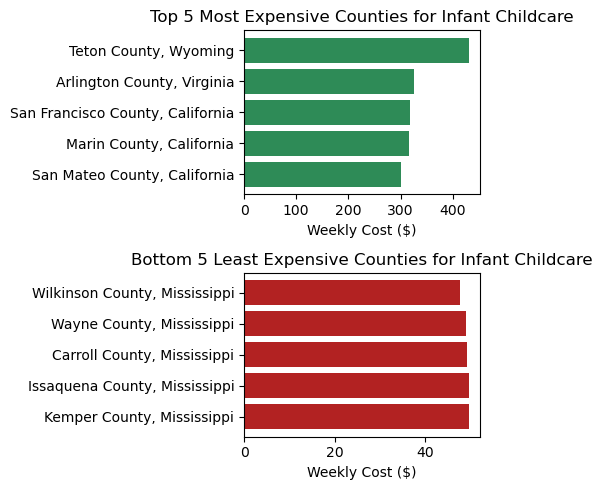

In [73]:
fig, axes = plt.subplots(nrows=2, figsize=(5,5),tight_layout=True)
axes[0].barh(top5['Label'], top5['MFCCInfant'], color='seagreen')
axes[0].set_title('Top 5 Most Expensive Counties for Infant Childcare')
axes[0].set_xlabel('Weekly Cost ($)')
axes[0].invert_yaxis()

axes[1].barh(bottom5['Label'], bottom5['MFCCInfant'], color='firebrick')
axes[1].set_title('Bottom 5 Least Expensive Counties for Infant Childcare')
axes[1].set_xlabel('Weekly Cost ($)')
axes[1].invert_yaxis()

Looking at infant phase, Wyoming and California seem to be most expensive state for Childcare whereas and Mississippi seems to be least expensive

This is one of the analysis I have started to compare the childcare costs. 

In [45]:
df_income = df[["State_Name", "County_Name", "MHI_2018"]].dropna()
df_income["MHI_2018"] = pd.to_numeric(df_income["MHI_2018"], errors="coerce")
df_income = df_income.dropna(subset=["MHI_2018"])

In [53]:
grouped_county = (df_income.groupby(["State_Name", "County_Name"])["MHI_2018"].median().sort_values(ascending=False))

top_5 = grouped_county.head(5).reset_index()
bottom_5 = grouped_county.tail(5).reset_index()

In [55]:
top_5["Label"] = top_5["County_Name"] + ", " + top_5["State_Name"]
bottom_5["Label"] = bottom_5["County_Name"] + ", " + bottom_5["State_Name"]

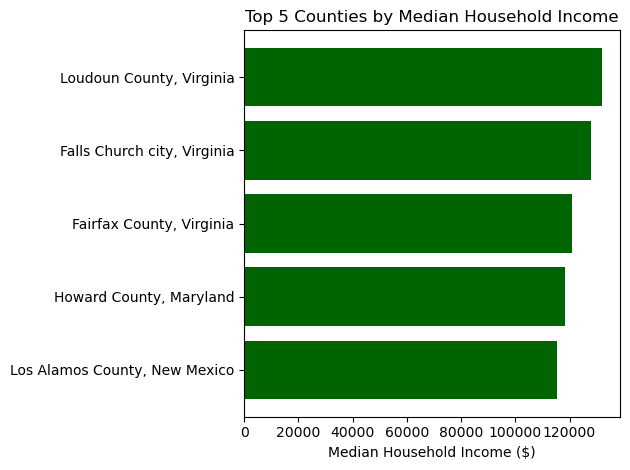

In [57]:
plt.barh(top_5["Label"], top_5["MHI_2018"], color="darkgreen")
plt.xlabel("Median Household Income ($)")
plt.title("Top 5 Counties by Median Household Income")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

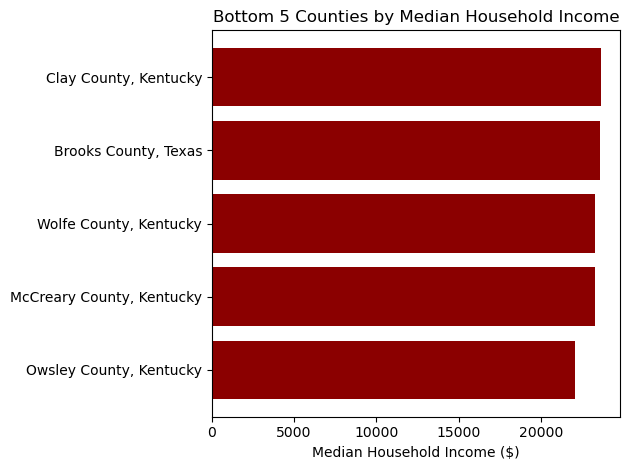

In [59]:
plt.barh(bottom_5["Label"], bottom_5["MHI_2018"], color="darkred")
plt.xlabel("Median Household Income ($)")
plt.title("Bottom 5 Counties by Median Household Income")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [38]:
df_infant = top5[['State_Name', 'MFCCInfant']].set_index('State_Name')

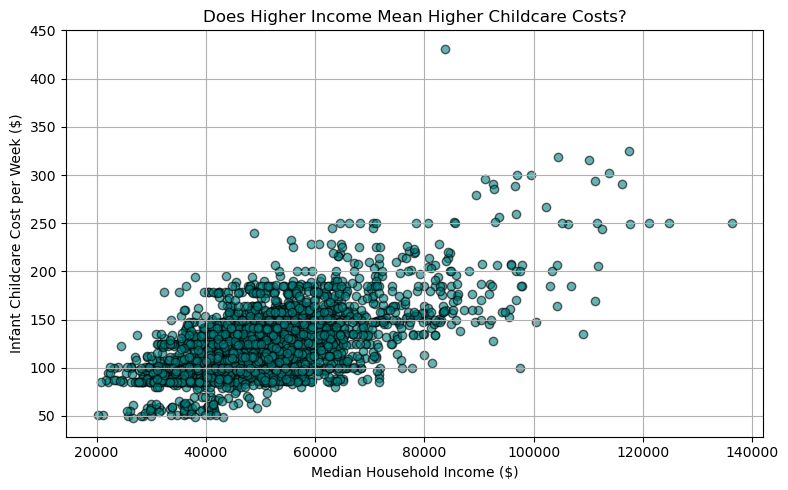

In [65]:
# Filter relevant columns
df_plot = df[['County_Name', 'State_Name', 'MHI', 'MFCCInfant', 'StudyYear']].dropna()

# Keep only latest year for each county
df_plot = df_plot.sort_values(['County_Name', 'State_Name', 'StudyYear'], ascending=[True, True, False])
df_plot = df_plot.drop_duplicates(subset=['County_Name', 'State_Name'])

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(df_plot['MHI'], df_plot['MFCCInfant'], alpha=0.6, color='teal', edgecolors='k')

plt.title('Does Higher Income Mean Higher Childcare Costs?')
plt.xlabel('Median Household Income ($)')
plt.ylabel('Infant Childcare Cost per Week ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

Milestone 4

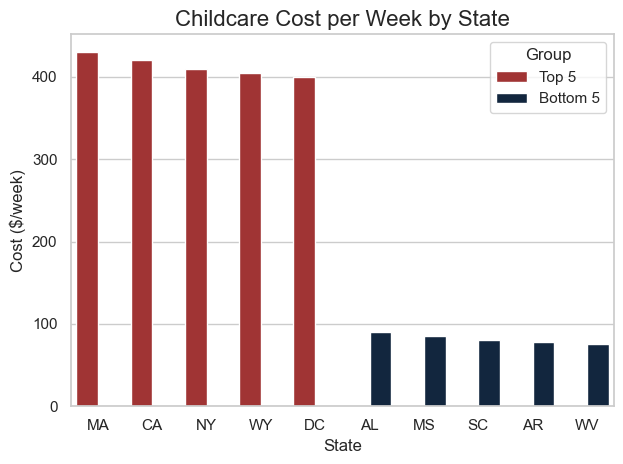

In [12]:
# Sample data: Top and Bottom 5 states by childcare cost
states = ['MA', 'CA', 'NY', 'WY', 'DC', 'AL', 'MS', 'SC', 'AR', 'WV']
costs = [430, 420, 410, 405, 400, 90, 85, 80, 78, 75]
categories = ['Top 5'] * 5 + ['Bottom 5'] * 5

# Create DataFrame
df = pd.DataFrame({
    'State': states,
    'Cost': costs,
    'Group': categories
})

# Create bar plot
sns.barplot(
    data=df,
    x='State',
    y='Cost',
    hue='Group',
    palette={'Top 5': '#B22222', 'Bottom 5': '#0B2545'}
)

# Customize chart
plt.title("Childcare Cost per Week by State", fontsize=16)
plt.ylabel("Cost ($/week)")
plt.xlabel("State")
plt.legend(title="Group", loc="upper right")
plt.tight_layout()

# Save chart to file
plt.savefig("social_media_bar_chart.png")
plt.show()

In [24]:
# Sample data
data = {
    'State': ['CA', 'MA', 'NY', 'WY', 'DC', 'AL', 'MS', 'SC', 'AR', 'WV'],
    'Childcare Cost': [430, 425, 420, 405, 410, 90, 85, 82, 78, 75],
    'Median Income': [85000, 87000, 84000, 76000, 79000, 42000, 40000, 41000, 39000, 39500]
}

# Create DataFrame and set index
df = pd.DataFrame(data)
df.set_index('State', inplace=True)

Heatmap of childcare cost

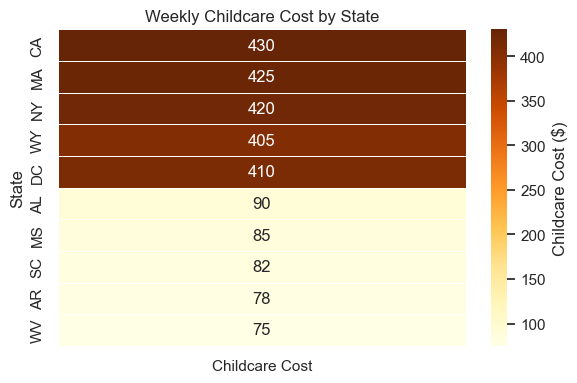

In [26]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    df[['Childcare Cost']],
    annot=True,
    cmap='YlOrBr',
    fmt='.0f',
    linewidths=0.5,
    cbar_kws={'label': 'Childcare Cost ($)'}
)
plt.title('Weekly Childcare Cost by State')
plt.tight_layout()
plt.show()

Heatmap of income by state

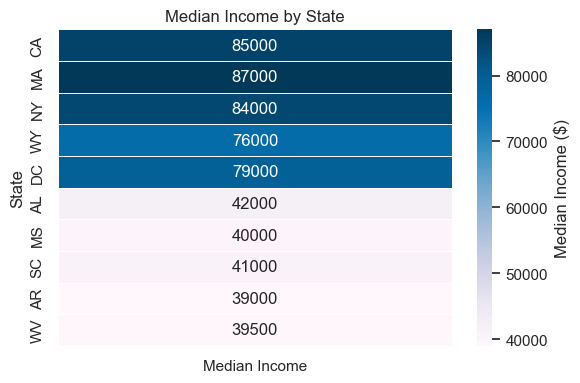

In [28]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    df[['Median Income']],
    annot=True,
    cmap='PuBu',
    fmt='.0f',
    linewidths=0.5,
    cbar_kws={'label': 'Median Income ($)'}
)
plt.title('Median Income by State')
plt.tight_layout()
plt.show()

In [27]:
# Load only the required columns from the Excel file
df = pd.read_excel("nationaldatabaseofchildcareprices.xlsx", sheet_name="nationaldatabaseofchildcare", usecols=["State_Name", "MFCCInfant", "MHI_2018", "TotalPop"])

# Drop missing values
df = df.dropna()

# Group by state and compute averages
grouped = df.groupby("State_Name").agg({
    "MFCCInfant": "mean",
    "MHI_2018": "median",
    "TotalPop": "sum"
}).reset_index()

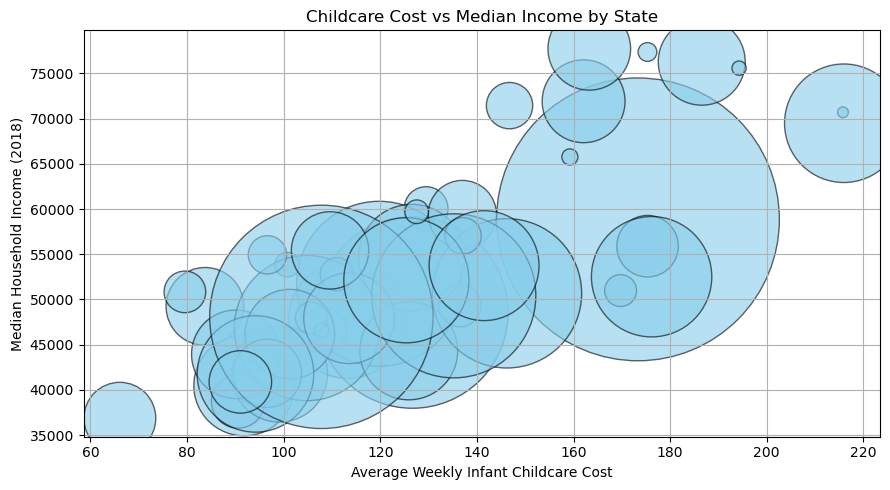

In [33]:
# Create bubble chart
plt.figure(figsize=(9,5))
plt.scatter(
    grouped["MFCCInfant"],
    grouped["MHI_2018"],
    s=grouped["TotalPop"] / 10000,
    alpha=0.6,
    c="skyblue",
    edgecolors="black"
)

plt.title("Childcare Cost vs Median Income by State")
plt.xlabel("Average Weekly Infant Childcare Cost")
plt.ylabel("Median Household Income (2018)")
plt.grid(True)
plt.tight_layout()
plt.show()